<a href="https://colab.research.google.com/github/pragnyavaleti/2520030238_ML/blob/main/project/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import pandas as pd
import numpy as np

In [48]:
import pandas as pd
import seaborn as sns

In [49]:
df = pd.read_excel('/content/crop_yield_merged_no_duplicates.xlsx')

df.head()

,Year,State,Crop,Season,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,2000,Andhra Pradesh,Arecanut,Whole Year,262.0,724.0,935.6,25720.54,68.12,2.780000
1,2000,Andhra Pradesh,Arhar/Tur,Kharif,507366.0,216457.0,935.6,49808120.22,131915.16,0.433182
2,2000,Andhra Pradesh,Bajra,Kharif,129475.0,135964.0,935.6,12710560.75,33663.50,1.001667
3,2000,Andhra Pradesh,Banana,Whole Year,49051.0,819660.0,935.6,4815336.67,12753.26,17.630909
4,2000,Andhra Pradesh,Cashewnut,Whole Year,145315.0,31074.0,935.6,14265573.55,37781.90,0.190625


In [50]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']
Categorical Features: ['State', 'Crop', 'Season']


In [51]:
corr_matrix = df[numerical_features].corr()

print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
                     Year      Area  Production  Annual_Rainfall  Fertilizer  \
Year             1.000000 -0.029065    0.001882         0.041067    0.005606   
Area            -0.029065  1.000000    0.042920        -0.157470    0.921001   
Production       0.001882  0.042920    1.000000         0.023949    0.045539   
Annual_Rainfall  0.041067 -0.157470    0.023949         1.000000   -0.124273   
Fertilizer       0.005606  0.921001    0.045539        -0.124273    1.000000   
Pesticide        0.006400  0.907713    0.044580        -0.122504    0.974538   
Yield            0.001194  0.002281    0.612960         0.016389    0.006580   

                 Pesticide     Yield  
Year              0.006400  0.001194  
Area              0.907713  0.002281  
Production        0.044580  0.612960  
Annual_Rainfall  -0.122504  0.016389  
Fertilizer        0.974538  0.006580  
Pesticide         1.000000  0.006261  
Yield             0.006261  1.000000  


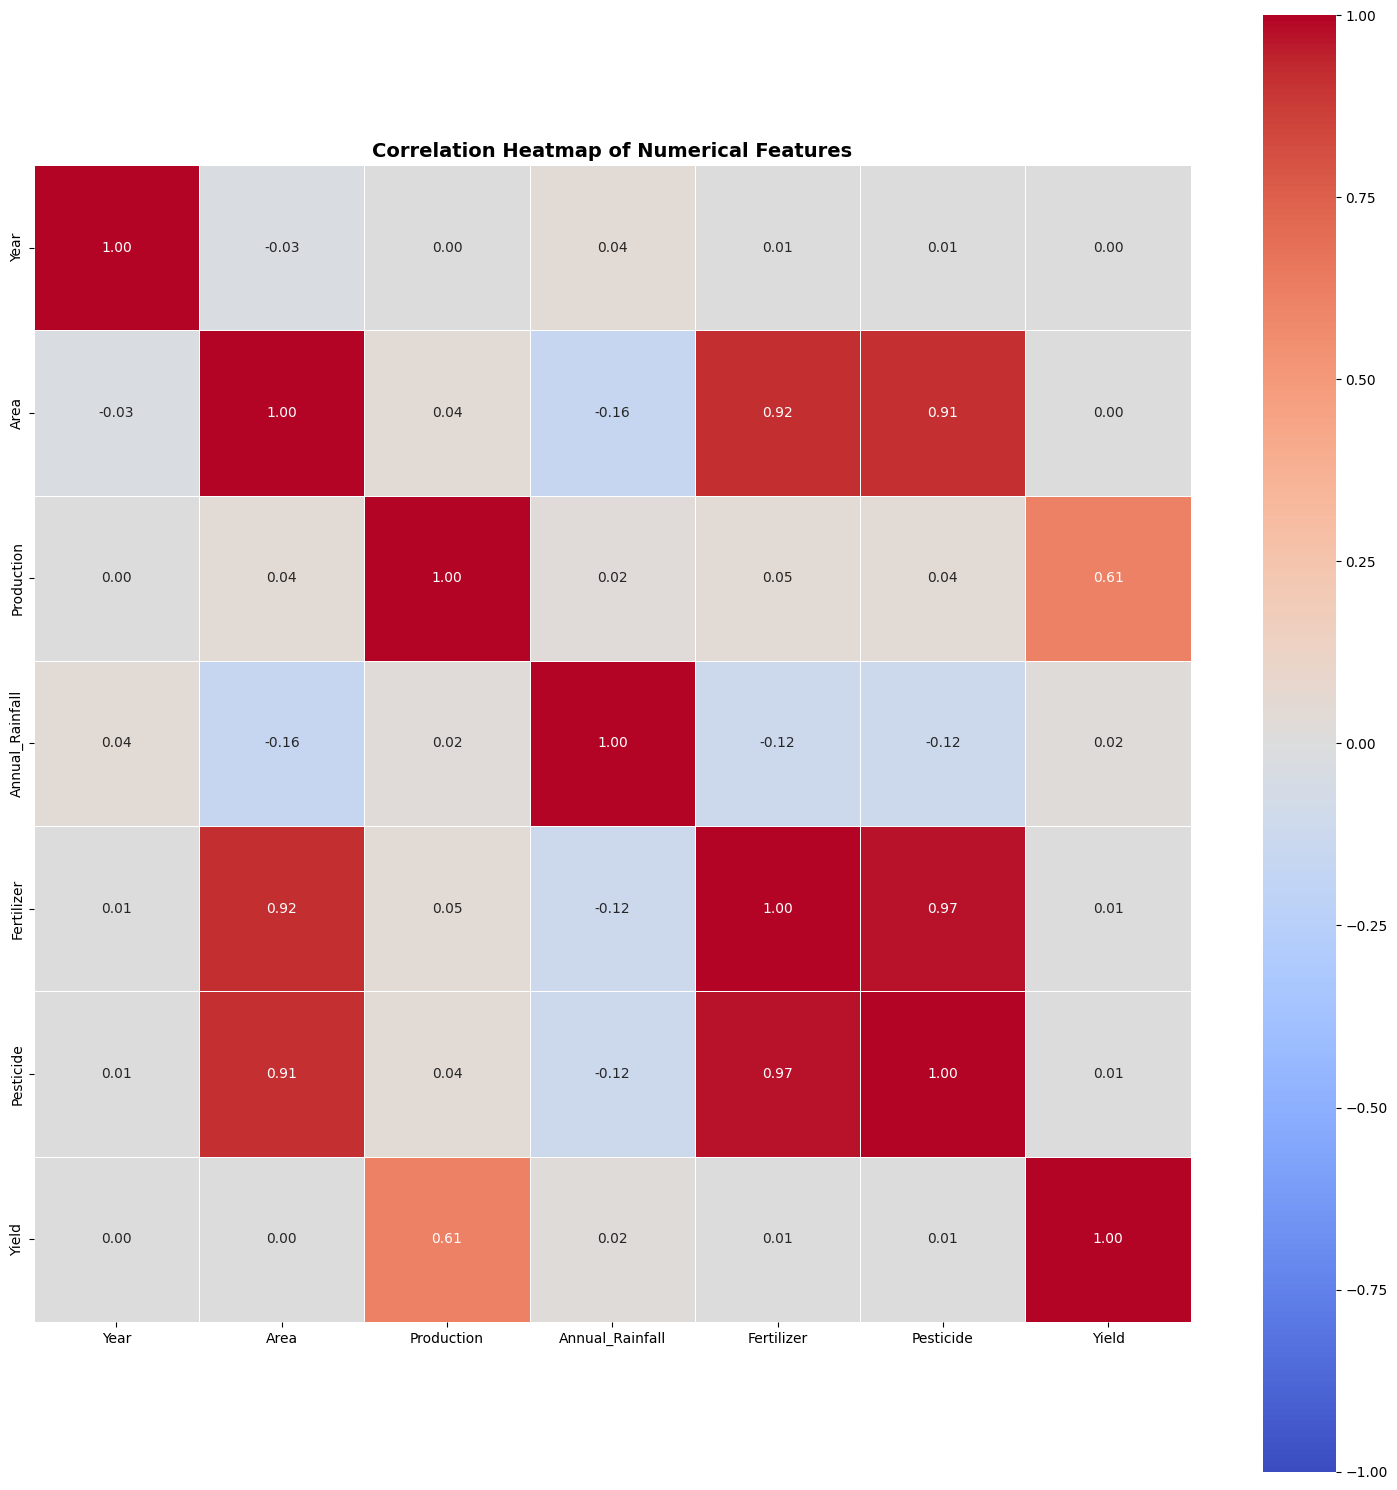

In [52]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

In [53]:
import os
output_dir = "/content/"
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.close()
print(f"Exported heatmap to: {heatmap_path}")

Exported heatmap to: /content/correlation_heatmap.png


In [62]:
import os

target_col = "Season"

numerical_cols = [
    "Area",
    "Production",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide",
    "Yield"
]

output_dir = "/content/eda_outputs"
os.makedirs(output_dir, exist_ok=True)

if target_col in df.columns:

    for col in numerical_cols:

        plt.figure(figsize=(6, 5))

        sns.boxplot(
            x=target_col,
            y=col,
            data=df,
            palette="Set2",
            hue=target_col,
            legend=False
        )

        plt.title(f"{col} vs {target_col}", fontsize=12, fontweight="bold")
        plt.xlabel(target_col)
        plt.ylabel(col)

        plt.tight_layout()

        # Save the boxplot
        boxplot_filename = f"boxplot_{col}_vs_{target_col}.png"

        # Create complete file path
        boxplot_path = os.path.join(output_dir, boxplot_filename)

        # Save the figure
        plt.savefig(boxplot_path, dpi=300, bbox_inches="tight")

        # Close the figure
        plt.close()

        # Display confirmation message
        print(f"Exported boxplot to: {boxplot_path}")

else:
    print(f"\nTarget column '{target_col}' not found in dataset. Skipping boxplots.")

print("\nAll EDA tasks completed successfully!")

Exported boxplot to: /content/eda_outputs/boxplot_Area_vs_Season.png
Exported boxplot to: /content/eda_outputs/boxplot_Production_vs_Season.png
Exported boxplot to: /content/eda_outputs/boxplot_Annual_Rainfall_vs_Season.png
Exported boxplot to: /content/eda_outputs/boxplot_Fertilizer_vs_Season.png
Exported boxplot to: /content/eda_outputs/boxplot_Pesticide_vs_Season.png
Exported boxplot to: /content/eda_outputs/boxplot_Yield_vs_Season.png

All EDA tasks completed successfully!


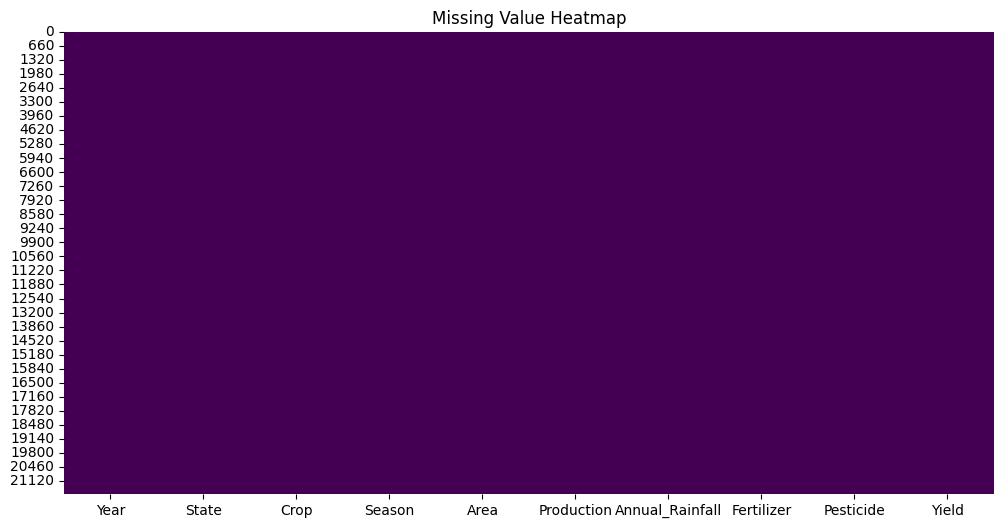

In [55]:
import matplotlib.pyplot as plt
fig1=plt.figure(figsize=(12,6))

sns.heatmap(
         df.isnull(),
        cbar=False,
         cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

<Figure size 1500x800 with 0 Axes>

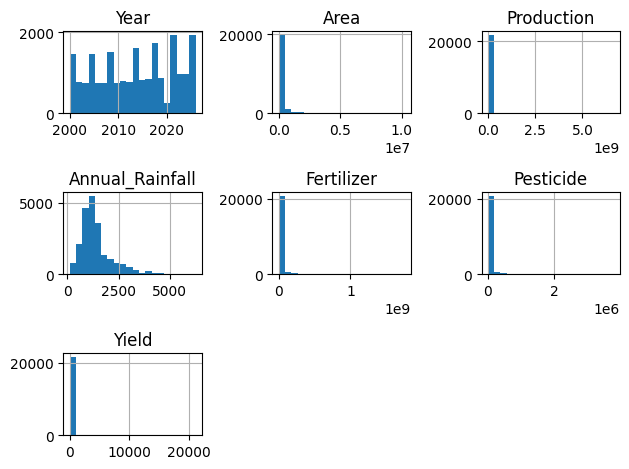

In [56]:
features = ["Year", "Area", "Production", "Annual_Rainfall", "Fertilizer", "Pesticide", "Yield"]

fig2 = plt.figure(figsize=(15,8))

df[features].hist(
    bins=20
)

plt.tight_layout()

plt.show()

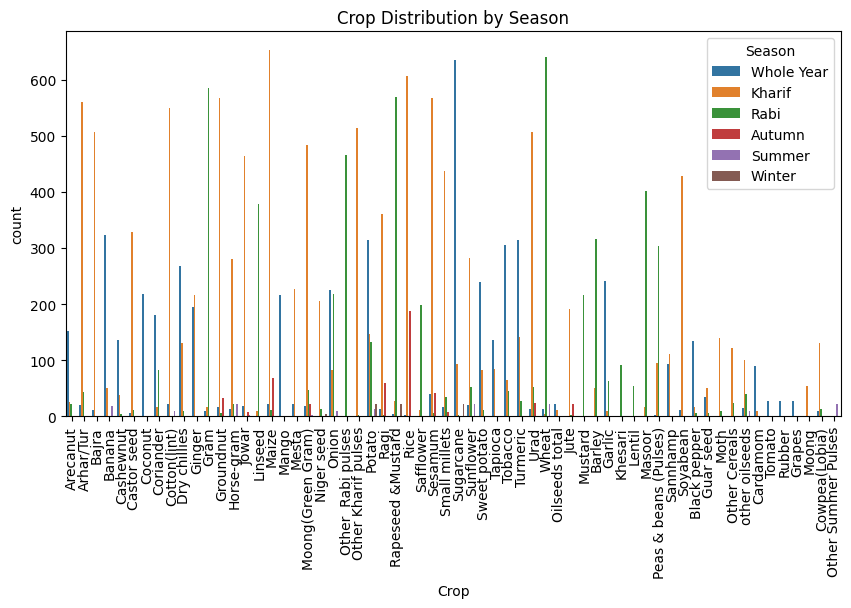

In [57]:
fig3 = plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Crop",
    hue="Season"
)

plt.title("Crop Distribution by Season")

plt.xticks(rotation=90)

plt.show()

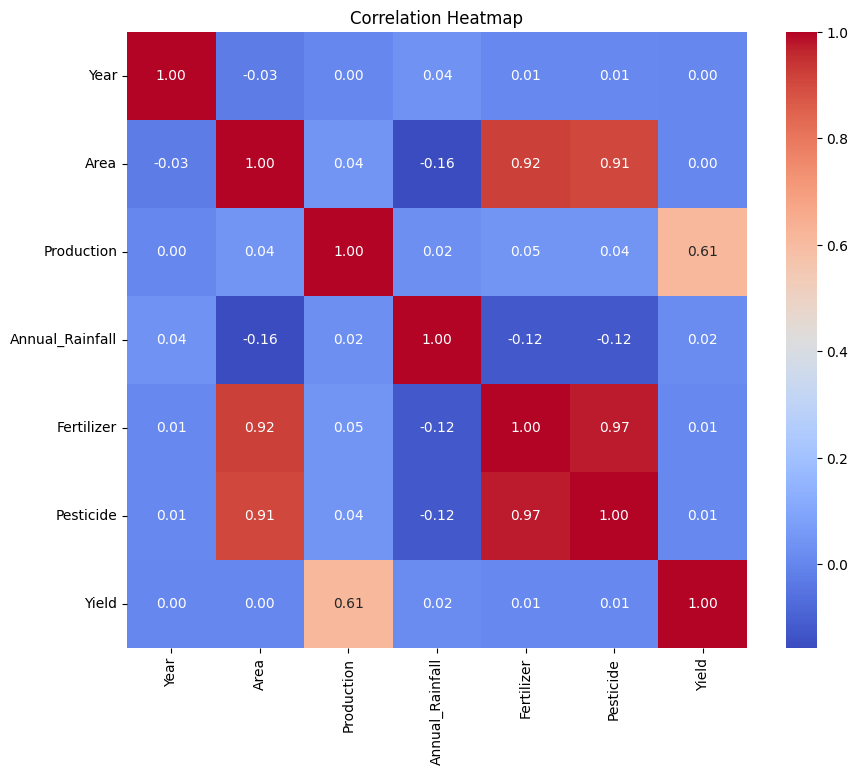

In [58]:
fig5= plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

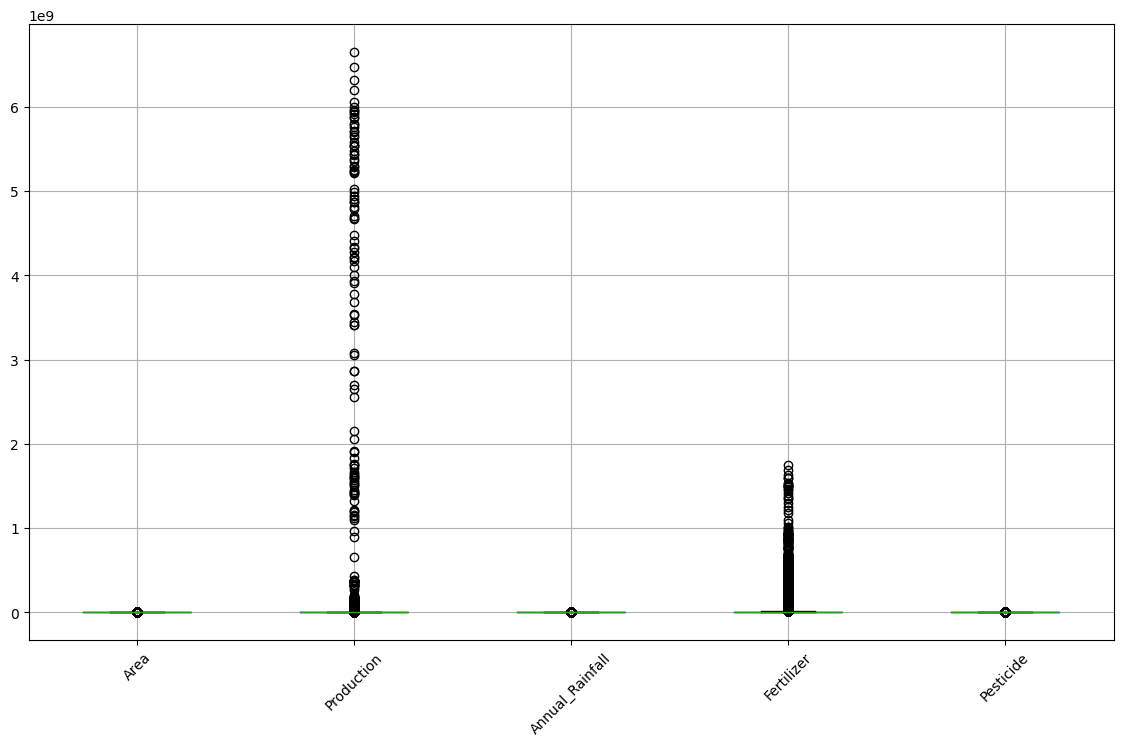

In [59]:

numerical_columns = [
    "Area",
    "Production",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide"

]


fig6= plt.figure(figsize=(14,8))

df[numerical_columns].boxplot()

plt.xticks(rotation=45)

plt.show()

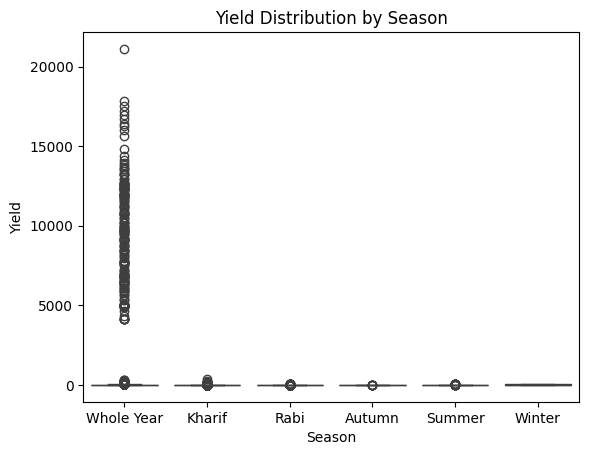

In [60]:
fig7 = sns.boxplot(x='Season', y='Yield', data=df)

plt.title("Yield Distribution by Season")

plt.show()

In [61]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages("EDA_Report.pdf") as pdf:

    pdf.savefig(fig1)
    pdf.savefig(fig2)
    pdf.savefig(fig3)
    pdf.savefig(fig5)
    pdf.savefig(fig6)
print("EDA Report saved successfully.")


EDA Report saved successfully.
